# Notebook 01 — Análisis Exploratorio de Datos (EDA)

**Proyecto:** Predicción de Churn en Telecomunicaciones  
**Dataset:** Telco Customer Churn  

En este notebook exploramos el dataset para entender su estructura, distribución de variables y relaciones relevantes antes del modelado.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

import warnings
warnings.filterwarnings('ignore')

## 2. Carga del dataset

Cargamos el archivo CSV desde la carpeta `data/processed/`. El dataset contiene información de clientes de una empresa de telecomunicaciones, incluyendo características del servicio contratado y si el cliente abandonó el servicio (churn).

In [2]:
df = pd.read_csv('../data/processed/Telco_customer_churn.csv')

print(f'Dimensiones del dataset: {df.shape}')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head()

Dimensiones del dataset: (7043, 33)
Filas: 7043 | Columnas: 33


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 3. Información general — `.info()`

`.info()` nos muestra los tipos de datos de cada columna, la cantidad de valores no nulos y el uso de memoria. Es el primer paso para detectar problemas de tipos y valores faltantes.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

## 4. Estadísticas descriptivas — `.describe()`

`.describe()` proporciona estadísticas de resumen de las variables numéricas: media, desviación estándar, mínimo, cuartiles y máximo. Incluimos `include='all'` para ver también variables categóricas.

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Análisis de valores nulos

Identificamos columnas con valores faltantes. Esto determina qué estrategias de imputación necesitaremos en el preprocesamiento.

In [5]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje
})
resumen_nulos = resumen_nulos[resumen_nulos['Valores nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

if resumen_nulos.empty:
    print('✓ No se encontraron valores nulos en el dataset.')
else:
    display(resumen_nulos)

,Valores nulos,Porcentaje (%)
Churn Reason,5174,73.46


> **Nota:** La columna `Total Charges` puede contener espacios en blanco en lugar de NaN cuando el cliente es nuevo (tenure = 0). Esto se tratará en el Notebook 02.

## 6. `.value_counts()` de variables categóricas clave

Exploramos la distribución de las principales variables categóricas para entender el perfil del cliente promedio.

In [6]:
categoricas = ['Contract', 'Internet Service', 'Payment Method', 'Gender', 'Churn Label']

for col in categoricas:
    print(f'\n=== {col} ===')
    print(df[col].value_counts())
    print(f'  Categorías únicas: {df[col].nunique()}')


=== Contract ===
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
  Categorías únicas: 3

=== Internet Service ===
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
  Categorías únicas: 3

=== Payment Method ===
Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64
  Categorías únicas: 4

=== Gender ===
Gender
Male      3555
Female    3488
Name: count, dtype: int64
  Categorías únicas: 2

=== Churn Label ===
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
  Categorías únicas: 2


## 7. Distribución de la variable objetivo: Churn

La variable objetivo es `Churn Label` (Yes/No). Graficamos su distribución para detectar desbalance de clases, lo cual impacta directamente en la elección del modelo y las métricas de evaluación.

In [7]:
churn_counts = df['Churn Label'].value_counts()
print('Distribución de Churn:')
print(churn_counts)
print(f'\nPorcentaje de churn (abandono): {churn_counts["Yes"]/len(df)*100:.1f}%')

Distribución de Churn:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de churn (abandono): 26.5%


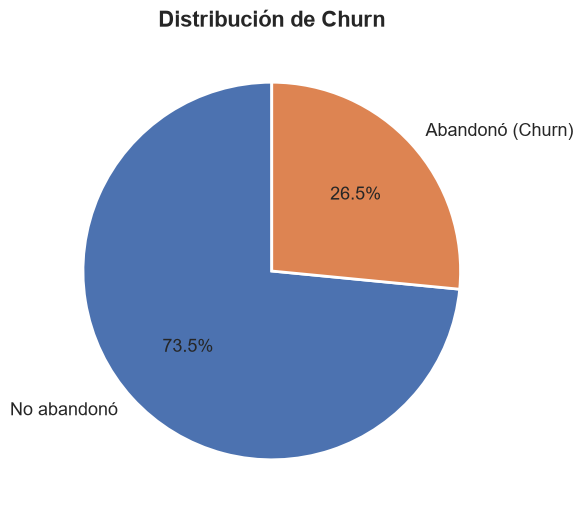

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    churn_counts,
    labels=['No abandonó', 'Abandonó (Churn)'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 13}
)
ax.set_title('Distribución de Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:** El dataset presenta un desbalance de clases moderado. Aproximadamente el **26-27% de los clientes abandonaron** el servicio. Esto significa que un clasificador trivial que siempre predice "No Churn" tendría ~73% de accuracy, por lo que el **F1-score** y el **AUC-ROC** son métricas más informativas que la simple exactitud.

## 8. Histogramas de variables numéricas

Graficamos la distribución de `Monthly Charges`, `Tenure Months` y `Total Charges`. La línea punteada indica la media de cada variable.

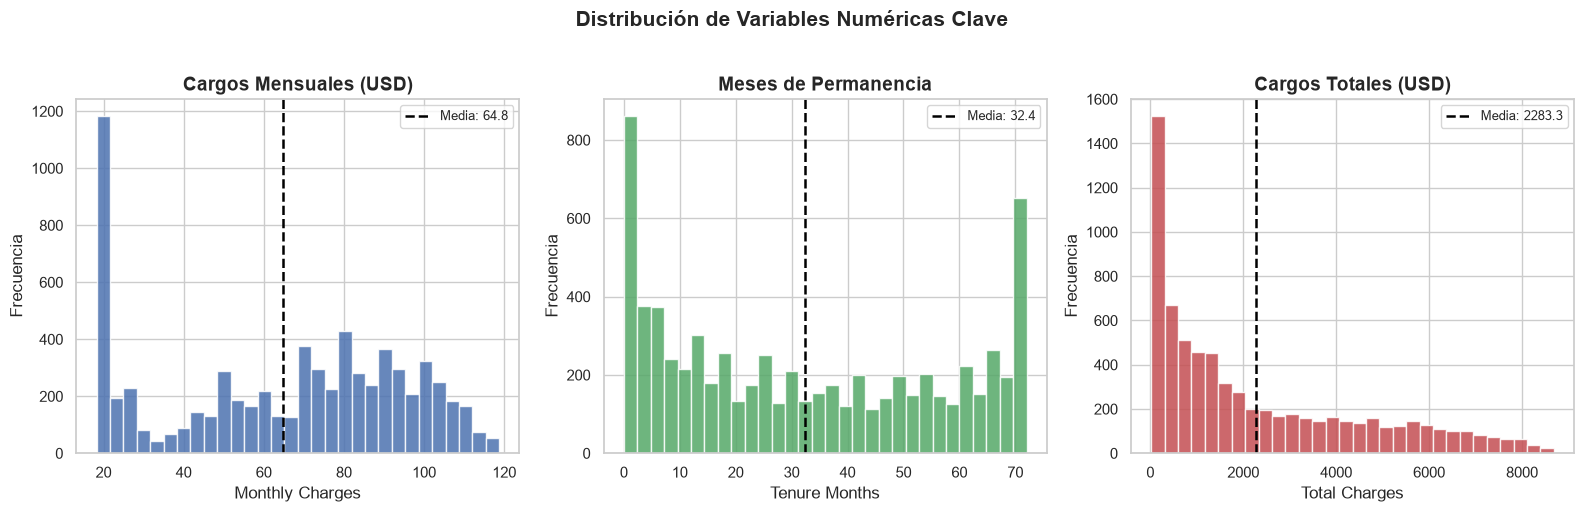

In [9]:
# Convertir Total Charges a numérico (clientes con tenure=0 tienen valor vacío)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables  = ['Monthly Charges', 'Tenure Months', 'Total Charges']
titulos    = ['Cargos Mensuales (USD)', 'Meses de Permanencia', 'Cargos Totales (USD)']
colores    = ['#4C72B0', '#55A868', '#C44E52']

for ax, var, titulo, color in zip(axes, variables, titulos, colores):
    datos = df[var].dropna()
    ax.hist(datos, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(datos.mean(), color='black', linestyle='--', linewidth=1.8,
               label=f'Media: {datos.mean():.1f}')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de Variables Numéricas Clave', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:**
- **Monthly Charges:** Distribución bimodal con concentraciones en valores bajos (~20 USD, clientes con servicio básico) y altos (~80-100 USD, clientes con múltiples servicios).
- **Tenure Months:** Muchos clientes son nuevos (1-2 meses) o muy antiguos (60-72 meses), con distribución relativamente plana en el rango medio.
- **Total Charges:** Sesgo a la derecha esperado: clientes con poco tiempo de permanencia acumulan cargos bajos.

## 9. Boxplots de Monthly Charges por tipo de contrato

Los boxplots permiten comparar la mediana, rango intercuartil y valores atípicos de los cargos mensuales para cada tipo de contrato.

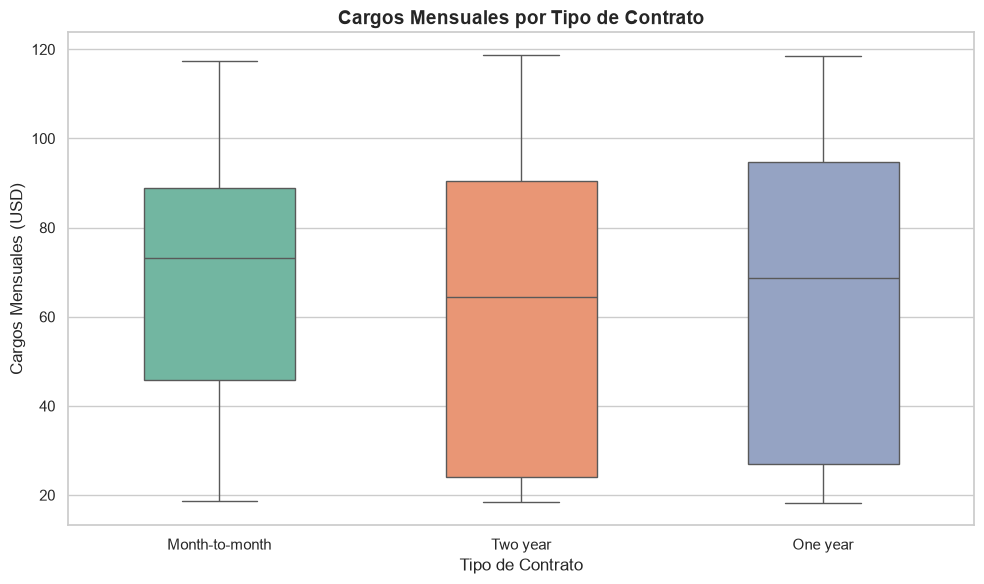

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Contract',
    y='Monthly Charges',
    palette='Set2',
    width=0.5,
    flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 4},
    ax=ax
)

ax.set_title('Cargos Mensuales por Tipo de Contrato', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Contrato', fontsize=12)
ax.set_ylabel('Cargos Mensuales (USD)', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretación:** Los contratos **mes a mes** presentan mayor variabilidad y generalmente cargos más altos. Los contratos de **un año** y **dos años** muestran distribuciones más compactas. Esto sugiere que los clientes en contratos de corto plazo con cargos elevados son el segmento de mayor riesgo de churn.

## 10. Mapa de calor de correlaciones

El mapa de calor muestra las correlaciones de Pearson entre variables numéricas. Valores cercanos a **+1** indican correlación positiva fuerte; valores cercanos a **-1**, correlación negativa fuerte.

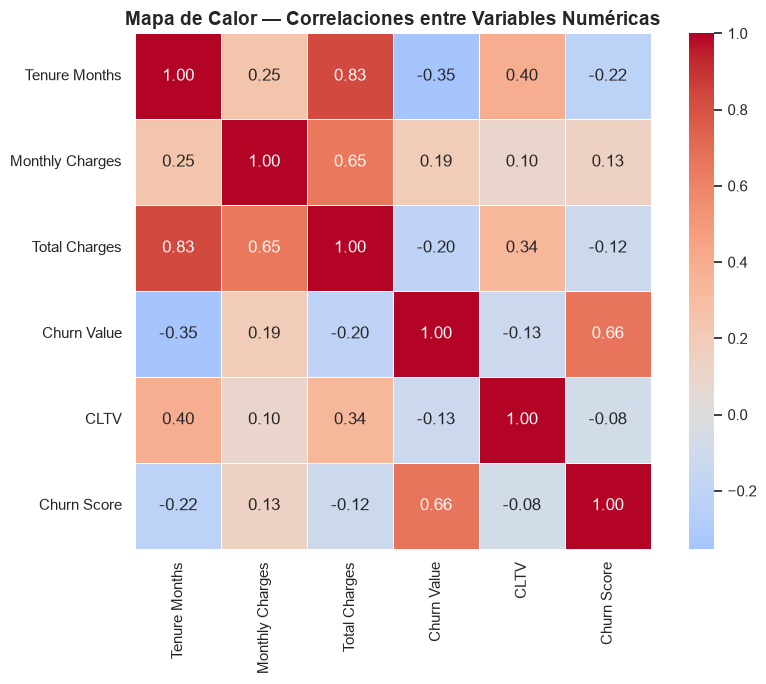

In [11]:
# Seleccionamos variables numéricas relevantes
cols_num = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV', 'Churn Score']
numericas = df[cols_num].copy()
numericas['Total Charges'] = pd.to_numeric(numericas['Total Charges'], errors='coerce')

corr_matrix = numericas.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # opcional: mostrar triángulo inferior
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Mapa de Calor — Correlaciones entre Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:**
- **`Tenure Months` ↔ `Total Charges`:** Correlación positiva alta (~0.83). Lógicamente, más tiempo de permanencia implica mayor acumulación de cargos.
- **`Churn Value` ↔ `Tenure Months`:** Correlación negativa. Los clientes con menor permanencia son más propensos al abandono.
- **`Churn Value` ↔ `Monthly Charges`:** Correlación positiva moderada. Cargos mensuales más altos se asocian con mayor probabilidad de churn.
- **`Churn Score` ↔ `Churn Value`:** Alta correlación esperada, ya que `Churn Score` es una estimación del riesgo de abandono.

## 11. Resumen del EDA

| Hallazgo | Detalle |
|---|---|
| **Dimensiones** | ~7.000 filas × 33 columnas |
| **Desbalance de clases** | ~73% No Churn / ~27% Churn |
| **Problema en `Total Charges`** | Valores vacíos en clientes con tenure = 0 (corregir con mediana) |
| **Correlación fuerte** | `Tenure Months` ↔ `Total Charges` (esperado) |
| **Factor de riesgo** | Clientes nuevos + cargos mensuales altos + contrato mes a mes |
| **Métrica recomendada** | F1-Score y AUC-ROC (por desbalance de clases) |

El siguiente paso es el **preprocesamiento** (Notebook 02) para limpiar, codificar y escalar los datos antes del modelado.